# Event Study
Compute CARs and run t-tests.

Event Study Results:
{'One-Sample': {'Purchases': {'Mean CAR': np.float64(-0.049610625111033244), 't-stat': np.float64(-2.330574344863189), 'p-val': np.float64(0.02814062260242102), '95% CI': (np.float64(-0.09345174747967486), np.float64(-0.00576950274239163))}, 'Sales': {'Mean CAR': np.float64(-0.024217068518497763), 't-stat': np.float64(-19.425844435429326), 'p-val': np.float64(2.7453883803775633e-79), '95% CI': (np.float64(-0.026661424335796075), np.float64(-0.021772712701199452))}}, 'Two-Sample (Welch)': {'t-stat': np.float64(-1.19088085091881), 'p-val': np.float64(0.2448096094682955)}, 'Wilcoxon': {'Purchases': {'w-stat': np.float64(101.0), 'p-val': np.float64(0.058450768968489775)}, 'Sales': {'w-stat': np.float64(1392157.0), 'p-val': np.float64(3.655686135246419e-75)}}}


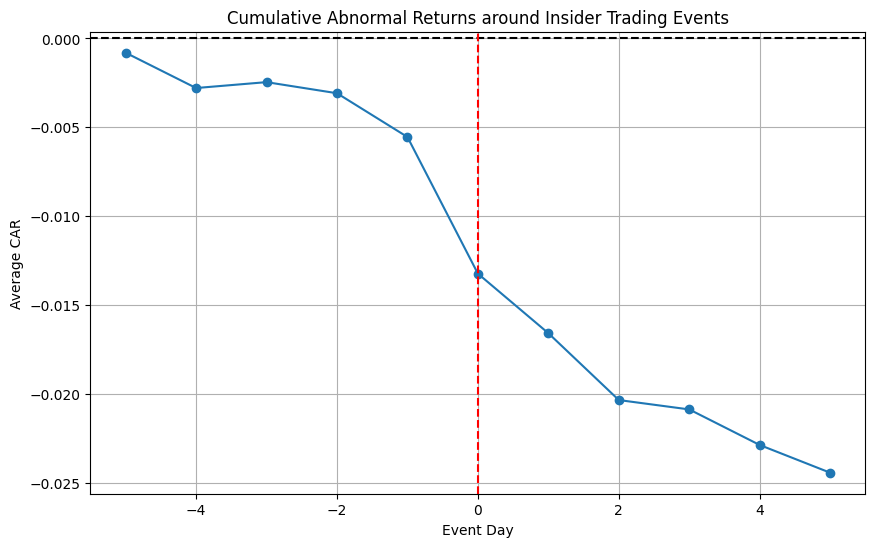

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../src')
import event_study

# Load data
events_df = pd.read_csv('../data/processed/events_with_market_model.csv')
events_df['TRANS_DATE'] = pd.to_datetime(events_df['TRANS_DATE'])
prices = pd.read_csv('../data/processed/stock_prices.csv', index_col='Date', parse_dates=True)
benchmark = pd.read_csv('../data/processed/market_benchmark.csv', index_col='Date', parse_dates=True)

firm_returns = prices.pct_change().dropna()
market_col = '^GSPC' if '^GSPC' in benchmark.columns else benchmark.columns[0]
market_returns = benchmark[market_col].pct_change().dropna()

cars = []
cars_by_day = []

for idx, row in events_df.iterrows():
    ticker = row['ISSUERTRADINGSYMBOL']
    event_date = row['TRANS_DATE']
    alpha = row['alpha']
    beta = row['beta']
    
    if ticker not in firm_returns.columns:
        continue
        
    f_ret = firm_returns[ticker]
    ar = event_study.compute_abnormal_returns(f_ret, market_returns, event_date, alpha, beta, event_window=(-5, 5))
    
    if ar is not None and len(ar) == 11:
        cars.append(ar.sum())
        cars_by_day.append(ar.values)
    else:
        cars.append(np.nan)

events_df['CAR'] = cars
events_df = events_df.dropna(subset=['CAR'])

# Split by Purchase / Sale
purchases = events_df[events_df['TRANS_CODE'] == 'P']['CAR']
sales = events_df[events_df['TRANS_CODE'] == 'S']['CAR']

# Run tests
results = event_study.run_event_study_tests(purchases, sales)
print("Event Study Results:")
print(results)

# Plot Average CAR
if len(cars_by_day) > 0:
    cars_by_day = np.array(cars_by_day)
    mean_ar = np.nanmean(cars_by_day, axis=0)
    mean_car = np.cumsum(mean_ar)

    plt.figure(figsize=(10,6))
    plt.plot(range(-5, 6), mean_car, marker='o')
    plt.title('Cumulative Abnormal Returns around Insider Trading Events')
    plt.xlabel('Event Day')
    plt.ylabel('Average CAR')
    plt.axhline(0, color='black', linestyle='--')
    plt.axvline(0, color='red', linestyle='--')
    plt.grid(True)
    plt.savefig('../report/car_plot.png')
    plt.show()

events_df.to_csv('../data/processed/events_with_car.csv', index=False)
